# Phase 7 — Unified Model Performance Analysis

This notebook is the data collector of the project.

It is work with:

- **YOLOv8** from `runs/detect/.../weights/best.pt`
- **Faster R-CNN** from `fasterrcnn_outputs/best_fasterrcnn_license_plate.pth`
- **RetinaNet** from `retinanet_outputs/best_retinanet_license_plate.pth`
- **Pascal VOC XML annotations** as ground truth
- optional training summaries from:
  - `runs/detect/.../results.csv`
  - `fasterrcnn_outputs/fasterrcnn_results.json`
  - `retinanet_outputs/retinanet_results.json`

## What this notebook does

1. discovers models and metadata
2. reads XML annotations directly
3. evaluates all models on the **same split**
4. computes:
   - detection rate
   - precision
   - recall
   - F1
   - AP@50
   - mAP@50:95
   - mean IoU of matched detections
   - speed per image
5. compares saved training histories when available
6. generates report-ready tables and plots
7. performs error analysis
8. optionally combines detection + OCR later if you want

In [1]:

# Uncomment if needed
# %pip install ultralytics torch torchvision pandas matplotlib pillow pyyaml

In [2]:

from __future__ import annotations

import os
import re
import json
import time
import math
import warnings
import xml.etree.ElementTree as ET
from pathlib import Path
from typing import Dict, List, Tuple, Optional, Any

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image

import torch
import torchvision
from torchvision.transforms import functional as TF

try:
    from ultralytics import YOLO
    ULTRALYTICS_AVAILABLE = True
except Exception as e:
    ULTRALYTICS_AVAILABLE = False
    print("Ultralytics import failed:", e)

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 200)
pd.set_option("display.max_colwidth", 200)

## 1) Configuration

Adjust these only if your folders are different.

This notebook tries to match the structure from your earlier notebooks:
- YOLO notebook
- Faster R-CNN notebook
- RetinaNet notebook
- OCR comparison notebook

In [ ]:

PROJECT_ROOT = Path.cwd()
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

# Primary dataset locations used in your previous notebooks
CARPLATE_DIR = PROJECT_ROOT / "carplate"
IMAGES_DIR = CARPLATE_DIR / "images"
ANNOTATIONS_DIR = CARPLATE_DIR / "annotations"
SPLIT_JSON = PROJECT_ROOT / "data_split.json"

YOLO_DATASET_DIR = PROJECT_ROOT / "dataset_yolo"
YOLO_DATA_YAML = YOLO_DATASET_DIR / "data.yaml"
FASTER_RESULTS_JSON = PROJECT_ROOT / "fasterrcnn_outputs" / "fasterrcnn_results.json"
RETINA_RESULTS_JSON = PROJECT_ROOT / "retinanet_outputs" / "retinanet_results.json"

FASTER_WEIGHT_CANDIDATES = [
    PROJECT_ROOT / "fasterrcnn_outputs" / "best_fasterrcnn_license_plate.pth",
    PROJECT_ROOT / "best_fasterrcnn_license_plate.pth",
]
RETINA_WEIGHT_CANDIDATES = [
    PROJECT_ROOT / "retinanet_outputs" / "best_retinanet_license_plate.pth",
    PROJECT_ROOT / "best_retinanet_license_plate.pth",
]

YOLO_WEIGHT_CANDIDATES = [
    PROJECT_ROOT / "runs" / "detect" / "plate_detector" / "weights" / "best.pt",
    PROJECT_ROOT / "runs" / "detect" / "train" / "weights" / "best.pt",
    PROJECT_ROOT / "runs" / "detect" / "train2" / "weights" / "best.pt",
    PROJECT_ROOT / "runs" / "detect" / "train3" / "weights" / "best.pt",
    PROJECT_ROOT / "best.pt",
]

ANALYSIS_DIR = PROJECT_ROOT / "analysis_outputs"
ANALYSIS_DIR.mkdir(exist_ok=True)

EVAL_IOU_PRIMARY = 0.50
EVAL_IOU_THRESHOLDS = np.arange(0.50, 1.00, 0.05)

RAW_CONF_THRESHOLD = 0.001
DISPLAY_CONF_THRESHOLD = 0.25
MAX_DETS_PER_IMAGE = 300

AUTO_TUNE_SCORE_THRESHOLDS = True
THRESHOLD_GRID = np.round(np.arange(0.05, 0.96, 0.05), 2)
DEFAULT_OPERATING_THRESHOLDS = {
    "YOLOv8": 0.25,
    "FasterRCNN": 0.50,
    "RetinaNet": 0.50,
}
APPLY_SCORE_FILTER_FOR_OPERATING_METRICS = True


FORCE_RESIZE_TORCHVISION = False
TORCHVISION_RESIZE_TO = (512, 512)

print("PROJECT_ROOT:", PROJECT_ROOT)
print("DEVICE:", DEVICE)
print("IMAGES_DIR exists:", IMAGES_DIR.exists(), IMAGES_DIR)
print("ANNOTATIONS_DIR exists:", ANNOTATIONS_DIR.exists(), ANNOTATIONS_DIR)
print("SPLIT_JSON exists:", SPLIT_JSON.exists(), SPLIT_JSON)
print("YOLO data.yaml exists:", YOLO_DATA_YAML.exists(), YOLO_DATA_YAML)
print("ANALYSIS_DIR:", ANALYSIS_DIR)


PROJECT_ROOT: C:\Users\jjrjg\OneDrive\Desktop\CMPS 261 Project\Plate-Detection-Project
DEVICE: cpu
IMAGES_DIR exists: True C:\Users\jjrjg\OneDrive\Desktop\CMPS 261 Project\Plate-Detection-Project\carplate\images
ANNOTATIONS_DIR exists: True C:\Users\jjrjg\OneDrive\Desktop\CMPS 261 Project\Plate-Detection-Project\carplate\annotations
SPLIT_JSON exists: True C:\Users\jjrjg\OneDrive\Desktop\CMPS 261 Project\Plate-Detection-Project\data_split.json
YOLO data.yaml exists: True C:\Users\jjrjg\OneDrive\Desktop\CMPS 261 Project\Plate-Detection-Project\dataset_yolo\data.yaml
ANALYSIS_DIR: C:\Users\jjrjg\OneDrive\Desktop\CMPS 261 Project\Plate-Detection-Project\analysis_outputs


## 2) Utility functions

In [4]:

def first_existing_path(*candidates) -> Optional[Path]:
    for candidate in candidates:
        candidate = Path(candidate)
        if candidate.exists():
            return candidate
    return None

def clean_stem(name: str) -> str:
    return Path(name).stem

def safe_float(x, default=np.nan):
    try:
        return float(x)
    except Exception:
        return default

def normalize_columns(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()
    df.columns = [
        str(c).strip()
        .replace("metrics/", "metrics_")
        .replace("train/", "train_")
        .replace("val/", "val_")
        .replace("(", "")
        .replace(")", "")
        .replace(" ", "_")
        .replace("-", "_")
        .replace("/", "_")
        .replace(":", "_")
        for c in df.columns
    ]
    df.columns = [re.sub(r"_+", "_", c) for c in df.columns]
    return df

def load_json(path: Path) -> Optional[dict]:
    if not Path(path).exists():
        return None
    with open(path, "r", encoding="utf-8") as f:
        return json.load(f)

def parse_voc_xml(xml_path: Path) -> dict:
    tree = ET.parse(xml_path)
    root = tree.getroot()

    filename = root.findtext("filename")
    size = root.find("size")
    width = int(size.findtext("width")) if size is not None and size.findtext("width") else None
    height = int(size.findtext("height")) if size is not None and size.findtext("height") else None

    objects = []
    for obj in root.findall("object"):
        name = obj.findtext("name", default="licence")
        bnd = obj.find("bndbox")
        if bnd is None:
            continue
        xmin = float(bnd.findtext("xmin"))
        ymin = float(bnd.findtext("ymin"))
        xmax = float(bnd.findtext("xmax"))
        ymax = float(bnd.findtext("ymax"))
        difficult = int(obj.findtext("difficult", default="0"))
        objects.append({
            "label": name,
            "bbox": [xmin, ymin, xmax, ymax],
            "difficult": difficult,
        })

    return {
        "xml_path": str(xml_path),
        "filename": filename,
        "image_stem": clean_stem(filename if filename else xml_path.stem),
        "width": width,
        "height": height,
        "objects": objects,
    }

def box_area(box: List[float]) -> float:
    x1, y1, x2, y2 = box
    return max(0.0, x2 - x1) * max(0.0, y2 - y1)

def compute_iou(box_a: List[float], box_b: List[float]) -> float:
    ax1, ay1, ax2, ay2 = box_a
    bx1, by1, bx2, by2 = box_b
    inter_x1 = max(ax1, bx1)
    inter_y1 = max(ay1, by1)
    inter_x2 = min(ax2, bx2)
    inter_y2 = min(ay2, by2)
    inter_w = max(0.0, inter_x2 - inter_x1)
    inter_h = max(0.0, inter_y2 - inter_y1)
    inter = inter_w * inter_h
    union = box_area(box_a) + box_area(box_b) - inter
    return inter / union if union > 0 else 0.0

def draw_boxes(image, gt_boxes=None, pred_boxes=None, pred_scores=None, title=""):
    img = image.copy()
    fig, ax = plt.subplots(figsize=(10, 6))
    ax.imshow(img)
    if gt_boxes:
        for b in gt_boxes:
            x1, y1, x2, y2 = b
            rect = plt.Rectangle((x1, y1), x2-x1, y2-y1, fill=False, linewidth=2)
            ax.add_patch(rect)
    if pred_boxes:
        for i, b in enumerate(pred_boxes):
            x1, y1, x2, y2 = b
            rect = plt.Rectangle((x1, y1), x2-x1, y2-y1, fill=False, linewidth=2, linestyle="--")
            ax.add_patch(rect)
            if pred_scores is not None and i < len(pred_scores):
                ax.text(x1, max(0, y1-3), f"{pred_scores[i]:.3f}", fontsize=9)
    ax.set_title(title)
    ax.axis("off")
    plt.show()

## 3) Discover the evaluation split

Priority used here:
1. `data_split.json` if present
2. XML files that correspond to images in `dataset_yolo/images/val`
3. otherwise all XML files in `carplate/annotations`


In [5]:

def discover_eval_stems() -> List[str]:
    if SPLIT_JSON.exists():
        data = load_json(SPLIT_JSON)
        if isinstance(data, dict):
            for key in ["test", "val", "valid", "validation"]:
                if key in data and isinstance(data[key], list) and len(data[key]) > 0:
                    return sorted({clean_stem(x) for x in data[key]})
    yolo_val_dir = YOLO_DATASET_DIR / "images" / "val"
    if yolo_val_dir.exists():
        stems = [p.stem for p in yolo_val_dir.iterdir() if p.suffix.lower() in {".jpg", ".jpeg", ".png", ".bmp"}]
        if stems:
            return sorted(set(stems))
    if ANNOTATIONS_DIR.exists():
        return sorted({p.stem for p in ANNOTATIONS_DIR.glob("*.xml")})
    return []

EVAL_STEMS = discover_eval_stems()
print(f"Number of evaluation images discovered: {len(EVAL_STEMS)}")
print("Sample:", EVAL_STEMS[:10])

Number of evaluation images discovered: 65
Sample: ['Cars0', 'Cars102', 'Cars106', 'Cars113', 'Cars12', 'Cars120', 'Cars126', 'Cars128', 'Cars136', 'Cars14']


In [6]:

def build_ground_truth_df(eval_stems: List[str]) -> pd.DataFrame:
    rows = []
    for stem in eval_stems:
        xml_path = ANNOTATIONS_DIR / f"{stem}.xml"
        if not xml_path.exists():
            continue
        parsed = parse_voc_xml(xml_path)
        for obj_idx, obj in enumerate(parsed["objects"]):
            rows.append({
                "image_stem": parsed["image_stem"],
                "xml_path": parsed["xml_path"],
                "width": parsed["width"],
                "height": parsed["height"],
                "gt_index": obj_idx,
                "label": obj["label"],
                "difficult": obj["difficult"],
                "xmin": obj["bbox"][0],
                "ymin": obj["bbox"][1],
                "xmax": obj["bbox"][2],
                "ymax": obj["bbox"][3],
                "gt_box": obj["bbox"],
            })
    return pd.DataFrame(rows)

gt_df = build_ground_truth_df(EVAL_STEMS)
print("Ground-truth rows:", len(gt_df))
gt_df.head()

Ground-truth rows: 71


,image_stem,xml_path,width,height,gt_index,label,difficult,xmin,ymin,xmax,ymax,gt_box
0,Cars0,C:\Users\jjrjg\OneDrive\Desktop\CMPS 261 Project\Plate-Detection-Project\carplate\annotations\Cars0.xml,500,268,0,licence,0,226.0,125.0,419.0,173.0,"[226.0, 125.0, 419.0, 173.0]"
1,Cars102,C:\Users\jjrjg\OneDrive\Desktop\CMPS 261 Project\Plate-Detection-Project\carplate\annotations\Cars102.xml,350,263,0,licence,0,66.0,147.0,322.0,199.0,"[66.0, 147.0, 322.0, 199.0]"
2,Cars106,C:\Users\jjrjg\OneDrive\Desktop\CMPS 261 Project\Plate-Detection-Project\carplate\annotations\Cars106.xml,400,247,0,licence,0,138.0,79.0,177.0,92.0,"[138.0, 79.0, 177.0, 92.0]"
3,Cars106,C:\Users\jjrjg\OneDrive\Desktop\CMPS 261 Project\Plate-Detection-Project\carplate\annotations\Cars106.xml,400,247,1,licence,0,245.0,79.0,270.0,94.0,"[245.0, 79.0, 270.0, 94.0]"
4,Cars106,C:\Users\jjrjg\OneDrive\Desktop\CMPS 261 Project\Plate-Detection-Project\carplate\annotations\Cars106.xml,400,247,2,licence,0,169.0,202.0,192.0,231.0,"[169.0, 202.0, 192.0, 231.0]"


## 4) Model discovery and loading



In [7]:

def auto_discover_yolo_models() -> List[dict]:
    discovered = []
    for p in YOLO_WEIGHT_CANDIDATES:
        if Path(p).exists():
            run_name = Path(p).parent.parent.name if Path(p).parent.parent.name else "root"
            discovered.append({
                "name": f"YOLOv8_{run_name}",
                "type": "yolo",
                "path": Path(p),
            })

    detect_root = PROJECT_ROOT / "runs" / "detect"
    if detect_root.exists():
        for best_path in detect_root.glob("*/weights/best.pt"):
            discovered.append({
                "name": f"YOLOv8_{best_path.parent.parent.name}",
                "type": "yolo",
                "path": best_path,
            })

    unique = []
    seen = set()
    for spec in discovered:
        key = str(Path(spec["path"]).resolve())
        if key not in seen:
            seen.add(key)
            unique.append(spec)
    return unique

AUTO_DISCOVERED_YOLO_MODELS = auto_discover_yolo_models()

FASTER_WEIGHTS = first_existing_path(*FASTER_WEIGHT_CANDIDATES)
RETINA_WEIGHTS = first_existing_path(*RETINA_WEIGHT_CANDIDATES)

MODEL_SPECS = []
MODEL_SPECS.extend(AUTO_DISCOVERED_YOLO_MODELS)

if FASTER_WEIGHTS and Path(FASTER_WEIGHTS).exists():
    MODEL_SPECS.append({
        "name": "FasterRCNN",
        "type": "torchvision",
        "arch": "fasterrcnn_resnet50_fpn",
        "num_classes": 2,
        "path": Path(FASTER_WEIGHTS),
    })

if RETINA_WEIGHTS and Path(RETINA_WEIGHTS).exists():
    MODEL_SPECS.append({
        "name": "RetinaNet",
        "type": "torchvision",
        "arch": "retinanet_resnet50_fpn",
        "num_classes": 2,
        "path": Path(RETINA_WEIGHTS),
    })

if not MODEL_SPECS:
    raise FileNotFoundError(
        "No model weights found. Check your project folders or update *_WEIGHT_CANDIDATES in the config cell."
    )

print("Detected model specs:")
for spec in MODEL_SPECS:
    print(spec)


Detected model specs:
{'name': 'FasterRCNN', 'type': 'torchvision', 'arch': 'fasterrcnn_resnet50_fpn', 'num_classes': 2, 'path': WindowsPath('C:/Users/jjrjg/OneDrive/Desktop/CMPS 261 Project/Plate-Detection-Project/fasterrcnn_outputs/best_fasterrcnn_license_plate.pth')}
{'name': 'RetinaNet', 'type': 'torchvision', 'arch': 'retinanet_resnet50_fpn', 'num_classes': 2, 'path': WindowsPath('C:/Users/jjrjg/OneDrive/Desktop/CMPS 261 Project/Plate-Detection-Project/retinanet_outputs/best_retinanet_license_plate.pth')}


In [8]:

def build_torchvision_detector(arch: str, num_classes: int):
    if arch == "fasterrcnn_resnet50_fpn":
        model = torchvision.models.detection.fasterrcnn_resnet50_fpn(
            weights=None,
            weights_backbone=None,
        )
        in_features = model.roi_heads.box_predictor.cls_score.in_features
        model.roi_heads.box_predictor = torchvision.models.detection.faster_rcnn.FastRCNNPredictor(
            in_features, num_classes
        )
        return model

    if arch == "retinanet_resnet50_fpn":
        return torchvision.models.detection.retinanet_resnet50_fpn(
            weights=None,
            weights_backbone=None,
            num_classes=num_classes,
        )

    if arch == "retinanet_resnet50_fpn_v2":
        return torchvision.models.detection.retinanet_resnet50_fpn_v2(
            weights=None,
            weights_backbone=None,
            num_classes=num_classes,
        )

    raise ValueError(f"Unsupported architecture: {arch}")

def extract_state_dict(checkpoint):
    if isinstance(checkpoint, torch.nn.Module):
        return None
    if not isinstance(checkpoint, dict):
        return checkpoint
    for key in ["model_state_dict", "state_dict", "model"]:
        if key in checkpoint and isinstance(checkpoint[key], dict):
            return checkpoint[key]
    return checkpoint

def load_torchvision_model_with_fallback(spec, device=DEVICE):
    checkpoint = torch.load(spec["path"], map_location=device)

    if isinstance(checkpoint, torch.nn.Module):
        model = checkpoint.to(device)
        model.eval()
        return model, spec["arch"], [], []

    state_dict = extract_state_dict(checkpoint)
    arch_candidates = [spec["arch"]]
    if spec["arch"] == "retinanet_resnet50_fpn":
        arch_candidates.append("retinanet_resnet50_fpn_v2")
    elif spec["arch"] == "retinanet_resnet50_fpn_v2":
        arch_candidates.append("retinanet_resnet50_fpn")

    seen = set()
    arch_candidates = [a for a in arch_candidates if not (a in seen or seen.add(a))]

    last_error = None
    for arch in arch_candidates:
        try:
            model = build_torchvision_detector(arch, int(spec.get("num_classes", 2))).to(device)
            missing, unexpected = model.load_state_dict(state_dict, strict=False)
            model.eval()
            return model, arch, missing, unexpected
        except Exception as e:
            last_error = e

    raise RuntimeError(f"Could not load {spec['name']} from {spec['path']}. Last error: {last_error}")

def load_model_from_spec(spec, device=DEVICE):
    if spec["type"] == "yolo":
        if not ULTRALYTICS_AVAILABLE:
            raise ImportError("Ultralytics is not installed/importable.")
        model = YOLO(str(spec["path"]))
        return {
            "name": spec["name"],
            "type": "yolo",
            "model": model,
            "path": Path(spec["path"]),
            "load_notes": "",
        }

    if spec["type"] == "torchvision":
        model, loaded_arch, missing, unexpected = load_torchvision_model_with_fallback(spec, device=device)
        return {
            "name": spec["name"],
            "type": "torchvision",
            "arch": loaded_arch,
            "model": model,
            "path": Path(spec["path"]),
            "load_notes": f"missing={len(missing)}, unexpected={len(unexpected)}",
        }

    raise ValueError(f"Unsupported model type: {spec['type']}")

loaded_models = []
for spec in MODEL_SPECS:
    bundle = load_model_from_spec(spec, device=DEVICE)
    loaded_models.append(bundle)
    print(f"Loaded {bundle['name']} from {bundle['path']} | notes: {bundle.get('load_notes','')}")

models = {m["name"]: m for m in loaded_models}
print("\nAvailable models:", list(models.keys()))

Loaded FasterRCNN from C:\Users\jjrjg\OneDrive\Desktop\CMPS 261 Project\Plate-Detection-Project\fasterrcnn_outputs\best_fasterrcnn_license_plate.pth | notes: missing=0, unexpected=0
Loaded RetinaNet from C:\Users\jjrjg\OneDrive\Desktop\CMPS 261 Project\Plate-Detection-Project\retinanet_outputs\best_retinanet_license_plate.pth | notes: missing=0, unexpected=0

Available models: ['FasterRCNN', 'RetinaNet']


## 5) Inference helpers

This notebook now keeps **raw predictions** at a very low confidence threshold for AP/mAP,
then computes a separate **operating-point summary** using an auto-tuned score threshold.



In [9]:

def get_image_path_from_stem(stem: str) -> Optional[Path]:
    for ext in [".jpg", ".jpeg", ".png", ".bmp"]:
        p = IMAGES_DIR / f"{stem}{ext}"
        if p.exists():
            return p
    matches = list(IMAGES_DIR.glob(f"{stem}.*"))
    return matches[0] if matches else None

def run_yolo_detector(image_bgr, model_bundle, conf=RAW_CONF_THRESHOLD, max_det=MAX_DETS_PER_IMAGE):
    model = model_bundle["model"]
    result = model.predict(source=image_bgr, conf=conf, max_det=max_det, verbose=False)[0]
    if result.boxes is None or len(result.boxes) == 0:
        return np.empty((0,4)), np.empty((0,)), np.empty((0,))
    boxes = result.boxes.xyxy.detach().cpu().numpy()
    scores = result.boxes.conf.detach().cpu().numpy()
    classes = result.boxes.cls.detach().cpu().numpy() if result.boxes.cls is not None else np.zeros(len(scores))
    return boxes, scores, classes

def maybe_resize_torchvision_input(image_rgb: np.ndarray):
    if not FORCE_RESIZE_TORCHVISION:
        return image_rgb, 1.0, 1.0
    orig_h, orig_w = image_rgb.shape[:2]
    new_w, new_h = TORCHVISION_RESIZE_TO
    pil_img = Image.fromarray(image_rgb).resize((new_w, new_h))
    resized = np.array(pil_img)
    scale_x = orig_w / new_w
    scale_y = orig_h / new_h
    return resized, scale_x, scale_y

def run_torchvision_detector(image_bgr, model_bundle, conf=RAW_CONF_THRESHOLD):
    model = model_bundle["model"]
    image_rgb = image_bgr[:, :, ::-1]
    image_rgb, scale_x, scale_y = maybe_resize_torchvision_input(image_rgb)
    tensor = TF.to_tensor(image_rgb).to(DEVICE)

    with torch.no_grad():
        outputs = model([tensor])[0]

    boxes = outputs.get("boxes", torch.empty((0, 4))).detach().cpu().numpy()
    scores = outputs.get("scores", torch.empty((0,))).detach().cpu().numpy()
    labels = outputs.get("labels", torch.empty((0,))).detach().cpu().numpy()

    if FORCE_RESIZE_TORCHVISION and len(boxes) > 0:
        boxes[:, [0, 2]] *= scale_x
        boxes[:, [1, 3]] *= scale_y

    if len(scores) == 0:
        return np.empty((0,4)), np.empty((0,)), np.empty((0,))

    keep = scores >= conf
    boxes = boxes[keep]
    scores = scores[keep]
    labels = labels[keep]
    return boxes, scores, labels

def run_detector(image_bgr, model_bundle, conf=RAW_CONF_THRESHOLD):
    if model_bundle["type"] == "yolo":
        return run_yolo_detector(image_bgr, model_bundle, conf=conf)
    if model_bundle["type"] == "torchvision":
        return run_torchvision_detector(image_bgr, model_bundle, conf=conf)
    raise ValueError(f"Unsupported model type: {model_bundle['type']}")


## 6) Collect predictions for all models

Each prediction row stores:
- image
- predicted box
- confidence
- class
- inference time

This is the raw material for all later metrics.

In [10]:

def collect_predictions_for_model(model_bundle, eval_stems: List[str], conf=RAW_CONF_THRESHOLD) -> pd.DataFrame:
    rows = []
    for stem in eval_stems:
        image_path = get_image_path_from_stem(stem)
        if image_path is None or not image_path.exists():
            continue

        image_bgr = np.array(Image.open(image_path).convert("RGB"))[:, :, ::-1]
        t0 = time.perf_counter()
        boxes, scores, labels = run_detector(image_bgr, model_bundle, conf=conf)
        elapsed = time.perf_counter() - t0

        if len(boxes) == 0:
            rows.append({
                "model_name": model_bundle["name"],
                "model_type": model_bundle["type"],
                "image_stem": stem,
                "image_path": str(image_path),
                "pred_index": -1,
                "score": 0.0,
                "label": -1,
                "xmin": np.nan,
                "ymin": np.nan,
                "xmax": np.nan,
                "ymax": np.nan,
                "pred_box": None,
                "inference_time_sec": elapsed,
                "num_preds_in_image": 0,
            })
        else:
            for i, (b, s, lbl) in enumerate(zip(boxes, scores, labels)):
                rows.append({
                    "model_name": model_bundle["name"],
                    "model_type": model_bundle["type"],
                    "image_stem": stem,
                    "image_path": str(image_path),
                    "pred_index": i,
                    "score": float(s),
                    "label": int(lbl),
                    "xmin": float(b[0]),
                    "ymin": float(b[1]),
                    "xmax": float(b[2]),
                    "ymax": float(b[3]),
                    "pred_box": [float(x) for x in b[:4]],
                    "inference_time_sec": elapsed,
                    "num_preds_in_image": int(len(boxes)),
                })
    return pd.DataFrame(rows)

all_pred_dfs = []
for model_name, model_bundle in models.items():
    print(f"Collecting predictions for {model_name} ...")
    pred_df = collect_predictions_for_model(model_bundle, EVAL_STEMS, conf=RAW_CONF_THRESHOLD)
    pred_path = ANALYSIS_DIR / f"{model_name}_raw_predictions.csv"
    pred_df.to_csv(pred_path, index=False)
    print(f"  saved -> {pred_path}")
    all_pred_dfs.append(pred_df)

pred_df = pd.concat(all_pred_dfs, ignore_index=True) if all_pred_dfs else pd.DataFrame()
print("Total prediction rows:", len(pred_df))
pred_df.head()

  saved -> C:\Users\jjrjg\OneDrive\Desktop\CMPS 261 Project\Plate-Detection-Project\analysis_outputs\FasterRCNN_raw_predictions.csv
  saved -> C:\Users\jjrjg\OneDrive\Desktop\CMPS 261 Project\Plate-Detection-Project\analysis_outputs\RetinaNet_raw_predictions.csv
Total prediction rows: 787


,model_name,model_type,image_stem,image_path,pred_index,score,label,xmin,ymin,xmax,ymax,pred_box,inference_time_sec,num_preds_in_image
0,FasterRCNN,torchvision,Cars0,C:\Users\jjrjg\OneDrive\Desktop\CMPS 261 Project\Plate-Detection-Project\carplate\images\Cars0.png,0,0.949651,1,234.721375,124.014137,408.010315,179.341660,"[234.72137451171875, 124.0141372680664, 408.01031494140625, 179.34165954589844]",8.427592,3
1,FasterRCNN,torchvision,Cars0,C:\Users\jjrjg\OneDrive\Desktop\CMPS 261 Project\Plate-Detection-Project\carplate\images\Cars0.png,1,0.082452,1,172.543274,108.230972,432.354370,200.011002,"[172.54327392578125, 108.23097229003906, 432.3543701171875, 200.01100158691406]",8.427592,3
2,FasterRCNN,torchvision,Cars0,C:\Users\jjrjg\OneDrive\Desktop\CMPS 261 Project\Plate-Detection-Project\carplate\images\Cars0.png,2,0.052394,1,304.481659,123.746788,397.270416,175.117386,"[304.4816589355469, 123.74678802490234, 397.2704162597656, 175.1173858642578]",8.427592,3
3,FasterRCNN,torchvision,Cars102,C:\Users\jjrjg\OneDrive\Desktop\CMPS 261 Project\Plate-Detection-Project\carplate\images\Cars102.png,0,0.811139,1,48.276993,135.835434,318.683716,208.223679,"[48.27699279785156, 135.83543395996094, 318.6837158203125, 208.2236785888672]",7.157320,4
4,FasterRCNN,torchvision,Cars102,C:\Users\jjrjg\OneDrive\Desktop\CMPS 261 Project\Plate-Detection-Project\carplate\images\Cars102.png,1,0.729210,1,164.444931,141.416687,317.118469,202.542923,"[164.44493103027344, 141.41668701171875, 317.11846923828125, 202.5429229736328]",7.157320,4


## 7) Matching predictions to ground truth

For a single-class detector, matching works like this:

- sort predictions by confidence
- for each prediction, find the best unmatched GT box in that image
- if IoU ≥ threshold → TP
- otherwise → FP
- remaining GTs → FN

This is done at:
- IoU = 0.50 for precision/recall/F1/AP50
- IoU = 0.50:0.95 step 0.05 for mAP@50:95

In [11]:

def build_gt_lookup(gt_df: pd.DataFrame) -> Dict[str, List[List[float]]]:
    lookup = {}
    if gt_df.empty:
        return lookup
    for stem, sub in gt_df.groupby("image_stem"):
        lookup[stem] = [list(b) for b in sub["gt_box"].tolist()]
    return lookup

gt_lookup = build_gt_lookup(gt_df)

def evaluate_model_at_iou(pred_df_model: pd.DataFrame, gt_lookup: dict, iou_thresh=0.5) -> Tuple[pd.DataFrame, dict]:
    pred_df_model = pred_df_model.copy()
    # remove placeholder rows with no boxes
    pred_df_model = pred_df_model[pred_df_model["pred_box"].notna()].copy()
    if len(pred_df_model) == 0:
        total_gts = sum(len(v) for v in gt_lookup.values())
        summary = {
            "iou_threshold": iou_thresh,
            "num_images": len(gt_lookup),
            "num_gt": total_gts,
            "num_predictions": 0,
            "tp": 0,
            "fp": 0,
            "fn": total_gts,
            "precision": 0.0,
            "recall": 0.0,
            "f1": 0.0,
            "ap": 0.0,
            "mean_matched_iou": np.nan,
        }
        return pd.DataFrame(), summary

    pred_df_model = pred_df_model.sort_values("score", ascending=False).reset_index(drop=True)

    gt_matched = {stem: np.zeros(len(gt_lookup.get(stem, [])), dtype=bool) for stem in gt_lookup.keys()}
    rows = []

    for _, row in pred_df_model.iterrows():
        stem = row["image_stem"]
        pred_box = row["pred_box"]
        gts = gt_lookup.get(stem, [])

        best_iou = 0.0
        best_gt_idx = -1
        for gt_idx, gt_box in enumerate(gts):
            if gt_matched[stem][gt_idx]:
                continue
            iou = compute_iou(pred_box, gt_box)
            if iou > best_iou:
                best_iou = iou
                best_gt_idx = gt_idx

        is_tp = int(best_gt_idx >= 0 and best_iou >= iou_thresh)
        if is_tp:
            gt_matched[stem][best_gt_idx] = True

        rows.append({
            "model_name": row["model_name"],
            "image_stem": stem,
            "score": row["score"],
            "pred_box": pred_box,
            "best_iou": best_iou,
            "matched_gt_index": best_gt_idx if is_tp else -1,
            "is_tp": is_tp,
            "is_fp": int(not is_tp),
            "iou_threshold": iou_thresh,
        })

    match_df = pd.DataFrame(rows)

    total_gt = sum(len(v) for v in gt_lookup.values())
    tp = int(match_df["is_tp"].sum()) if not match_df.empty else 0
    fp = int(match_df["is_fp"].sum()) if not match_df.empty else 0
    fn = int(total_gt - tp)

    precision = tp / (tp + fp) if (tp + fp) > 0 else 0.0
    recall = tp / total_gt if total_gt > 0 else 0.0
    f1 = 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0.0

    if not match_df.empty:
        match_df["cum_tp"] = match_df["is_tp"].cumsum()
        match_df["cum_fp"] = match_df["is_fp"].cumsum()
        match_df["precision_curve"] = match_df["cum_tp"] / (match_df["cum_tp"] + match_df["cum_fp"])
        match_df["recall_curve"] = match_df["cum_tp"] / max(total_gt, 1)

        # VOC/COCO-style interpolation over recall
        recall_points = np.linspace(0, 1, 101)
        precisions_interp = []
        for r in recall_points:
            eligible = match_df.loc[match_df["recall_curve"] >= r, "precision_curve"]
            precisions_interp.append(float(eligible.max()) if len(eligible) > 0 else 0.0)
        ap = float(np.mean(precisions_interp))
        mean_matched_iou = float(match_df.loc[match_df["is_tp"] == 1, "best_iou"].mean()) if tp > 0 else np.nan
    else:
        ap = 0.0
        mean_matched_iou = np.nan

    summary = {
        "iou_threshold": iou_thresh,
        "num_images": len(gt_lookup),
        "num_gt": total_gt,
        "num_predictions": len(pred_df_model),
        "tp": tp,
        "fp": fp,
        "fn": fn,
        "precision": precision,
        "recall": recall,
        "f1": f1,
        "ap": ap,
        "mean_matched_iou": mean_matched_iou,
    }
    return match_df, summary

def apply_score_threshold(pred_df_model: pd.DataFrame, score_threshold: float) -> pd.DataFrame:
    pred_df_model = pred_df_model.copy()
    if pred_df_model.empty:
        return pred_df_model
    mask_no_box = pred_df_model["pred_box"].isna()
    mask_keep = mask_no_box | (pred_df_model["score"].fillna(0.0) >= float(score_threshold))
    return pred_df_model[mask_keep].copy()

def choose_best_score_threshold(pred_df_model: pd.DataFrame, gt_lookup: dict,
                                threshold_grid=None, iou_thresh=0.50,
                                optimize_for="f1") -> tuple[float, pd.DataFrame]:
    if threshold_grid is None:
        threshold_grid = THRESHOLD_GRID

    rows = []
    best_threshold = DEFAULT_OPERATING_THRESHOLDS.get(
        str(pred_df_model["model_name"].dropna().iloc[0]) if not pred_df_model.empty else "",
        0.50
    )
    best_value = -np.inf

    for thr in threshold_grid:
        filtered = apply_score_threshold(pred_df_model, float(thr))
        _, summary = evaluate_model_at_iou(filtered, gt_lookup, iou_thresh=iou_thresh)
        value = float(summary.get(optimize_for, np.nan))
        rows.append({
            "score_threshold": float(thr),
            "precision": float(summary.get("precision", np.nan)),
            "recall": float(summary.get("recall", np.nan)),
            "f1": float(summary.get("f1", np.nan)),
            "ap": float(summary.get("ap", np.nan)),
            "num_predictions": int(summary.get("num_predictions", 0)),
            "tp": int(summary.get("tp", 0)),
            "fp": int(summary.get("fp", 0)),
            "fn": int(summary.get("fn", 0)),
        })
        tie_break = float(summary.get("precision", -np.inf))
        if np.isfinite(value) and (value > best_value or (value == best_value and tie_break > rows[-1]["precision"])):
            best_value = value
            best_threshold = float(thr)

    sweep_df = pd.DataFrame(rows)
    return best_threshold, sweep_df


In [12]:

per_model_primary = []
per_model_all_thresholds = []
per_model_operating = []
per_model_threshold_sweeps = []
match_dfs = []

for model_name in pred_df["model_name"].dropna().unique():
    sub = pred_df[pred_df["model_name"] == model_name].copy()

    # Raw low-threshold evaluation for AP / mAP only
    match_df_50, raw_summary_50 = evaluate_model_at_iou(sub, gt_lookup, iou_thresh=0.50)
    match_df_50["model_name"] = model_name
    match_dfs.append(match_df_50)

    inference_stats = sub.groupby("image_stem", as_index=False)["inference_time_sec"].max()

    raw_summary_50["model_name"] = model_name
    raw_summary_50["raw_precision"] = float(raw_summary_50.get("precision", np.nan))
    raw_summary_50["raw_recall"] = float(raw_summary_50.get("recall", np.nan))
    raw_summary_50["raw_f1"] = float(raw_summary_50.get("f1", np.nan))
    raw_summary_50["raw_num_predictions"] = int(raw_summary_50.get("num_predictions", 0))
    raw_summary_50["mean_inference_time_sec"] = float(inference_stats["inference_time_sec"].mean()) if len(inference_stats) else np.nan
    raw_summary_50["images_per_second"] = (
        1.0 / raw_summary_50["mean_inference_time_sec"]
        if pd.notna(raw_summary_50["mean_inference_time_sec"]) and raw_summary_50["mean_inference_time_sec"] > 0
        else np.nan
    )

    # AP / mAP on raw predictions
    aps = []
    for thr in EVAL_IOU_THRESHOLDS:
        _, summary_thr = evaluate_model_at_iou(sub, gt_lookup, iou_thresh=float(thr))
        summary_thr["model_name"] = model_name
        per_model_all_thresholds.append(summary_thr)
        aps.append(summary_thr["ap"])

    raw_summary_50["mAP50_95"] = float(np.mean(aps)) if len(aps) else np.nan
    raw_summary_50["AP50"] = float(raw_summary_50.get("ap", np.nan))

    # Operating-point summary using score-threshold tuning on cached raw predictions
    if AUTO_TUNE_SCORE_THRESHOLDS:
        best_threshold, threshold_sweep_df = choose_best_score_threshold(
            sub,
            gt_lookup,
            threshold_grid=THRESHOLD_GRID,
            iou_thresh=0.50,
            optimize_for="f1",
        )
    else:
        best_threshold = float(DEFAULT_OPERATING_THRESHOLDS.get(model_name, 0.50))
        threshold_sweep_df = pd.DataFrame()

    operating_sub = apply_score_threshold(sub, best_threshold) if APPLY_SCORE_FILTER_FOR_OPERATING_METRICS else sub
    _, operating_summary = evaluate_model_at_iou(operating_sub, gt_lookup, iou_thresh=0.50)

    raw_summary_50["operating_score_threshold"] = float(best_threshold)
    raw_summary_50["precision"] = float(operating_summary.get("precision", np.nan))
    raw_summary_50["recall"] = float(operating_summary.get("recall", np.nan))
    raw_summary_50["f1"] = float(operating_summary.get("f1", np.nan))
    raw_summary_50["num_predictions"] = int(operating_summary.get("num_predictions", 0))
    raw_summary_50["tp"] = int(operating_summary.get("tp", 0))
    raw_summary_50["fp"] = int(operating_summary.get("fp", 0))
    raw_summary_50["fn"] = int(operating_summary.get("fn", 0))
    raw_summary_50["mean_matched_iou"] = float(operating_summary.get("mean_matched_iou", np.nan))

    per_model_primary.append(raw_summary_50)

    if not threshold_sweep_df.empty:
        threshold_sweep_df["model_name"] = model_name
        per_model_threshold_sweeps.append(threshold_sweep_df)

summary_df = pd.DataFrame(per_model_primary)
all_thresholds_df = pd.DataFrame(per_model_all_thresholds)
all_matches_df = pd.concat(match_dfs, ignore_index=True) if match_dfs else pd.DataFrame()
threshold_sweeps_df = pd.concat(per_model_threshold_sweeps, ignore_index=True) if per_model_threshold_sweeps else pd.DataFrame()

if not summary_df.empty:
    summary_df = summary_df.sort_values(["mAP50_95", "AP50", "f1", "precision", "recall"], ascending=False).reset_index(drop=True)

summary_path = ANALYSIS_DIR / "phase7_detection_summary.csv"
thresholds_path = ANALYSIS_DIR / "phase7_detection_all_thresholds.csv"
matches_path = ANALYSIS_DIR / "phase7_detection_matches.csv"
sweeps_path = ANALYSIS_DIR / "phase7_threshold_sweeps.csv"

summary_df.to_csv(summary_path, index=False)
all_thresholds_df.to_csv(thresholds_path, index=False)
all_matches_df.to_csv(matches_path, index=False)
threshold_sweeps_df.to_csv(sweeps_path, index=False)

print("Saved summary to:", summary_path)
print("Saved threshold-wise metrics to:", thresholds_path)
print("Saved match details to:", matches_path)
print("Saved score-threshold sweeps to:", sweeps_path)

summary_df


Saved summary to: C:\Users\jjrjg\OneDrive\Desktop\CMPS 261 Project\Plate-Detection-Project\analysis_outputs\phase7_detection_summary.csv
Saved threshold-wise metrics to: C:\Users\jjrjg\OneDrive\Desktop\CMPS 261 Project\Plate-Detection-Project\analysis_outputs\phase7_detection_all_thresholds.csv
Saved match details to: C:\Users\jjrjg\OneDrive\Desktop\CMPS 261 Project\Plate-Detection-Project\analysis_outputs\phase7_detection_matches.csv
Saved score-threshold sweeps to: C:\Users\jjrjg\OneDrive\Desktop\CMPS 261 Project\Plate-Detection-Project\analysis_outputs\phase7_threshold_sweeps.csv


,iou_threshold,num_images,num_gt,num_predictions,tp,fp,fn,precision,recall,f1,ap,mean_matched_iou,model_name,raw_precision,raw_recall,raw_f1,raw_num_predictions,mean_inference_time_sec,images_per_second,mAP50_95,AP50,operating_score_threshold
0,0.5,65,71,81,60,21,11,0.740741,0.845070,0.789474,0.825362,0.760570,RetinaNet,0.104294,0.957746,0.188105,652,6.512425,0.153553,0.424247,0.825362,0.40
1,0.5,65,71,67,59,8,12,0.880597,0.830986,0.855072,0.832425,0.760092,FasterRCNN,0.462121,0.859155,0.600985,132,7.099743,0.140850,0.389281,0.832425,0.35


## 8) Add model size information

This is useful in the report because it gives a practical comparison:
- not just accuracy
- also storage cost and rough deployment friendliness

In [13]:

def file_size_mb(path: Path) -> float:
    return Path(path).stat().st_size / (1024 * 1024) if Path(path).exists() else np.nan

size_rows = []
for m in loaded_models:
    size_rows.append({
        "model_name": m["name"],
        "weights_path": str(m["path"]),
        "weights_size_mb": file_size_mb(m["path"]),
        "model_type": m["type"],
    })
size_df = pd.DataFrame(size_rows)

summary_df = summary_df.merge(size_df[["model_name", "weights_size_mb", "weights_path", "model_type"]], on="model_name", how="left")
summary_df = summary_df.sort_values(["mAP50_95", "AP50", "f1"], ascending=False).reset_index(drop=True)
summary_df

,iou_threshold,num_images,num_gt,num_predictions,tp,fp,fn,precision,recall,f1,ap,mean_matched_iou,model_name,raw_precision,raw_recall,raw_f1,raw_num_predictions,mean_inference_time_sec,images_per_second,mAP50_95,AP50,operating_score_threshold,weights_size_mb,weights_path,model_type
0,0.5,65,71,81,60,21,11,0.740741,0.845070,0.789474,0.825362,0.760570,RetinaNet,0.104294,0.957746,0.188105,652,6.512425,0.153553,0.424247,0.825362,0.40,123.225422,C:\Users\jjrjg\OneDrive\Desktop\CMPS 261 Project\Plate-Detection-Project\retinanet_outputs\best_retinanet_license_plate.pth,torchvision
1,0.5,65,71,67,59,8,12,0.880597,0.830986,0.855072,0.832425,0.760092,FasterRCNN,0.462121,0.859155,0.600985,132,7.099743,0.140850,0.389281,0.832425,0.35,158.052749,C:\Users\jjrjg\OneDrive\Desktop\CMPS 261 Project\Plate-Detection-Project\fasterrcnn_outputs\best_fasterrcnn_license_plate.pth,torchvision


## 9) comparison table


In [14]:

report_table = summary_df[[
    "model_name",
    "model_type",
    "num_images",
    "num_gt",
    "num_predictions",
    "operating_score_threshold",
    "precision",
    "recall",
    "f1",
    "AP50",
    "mAP50_95",
    "mean_matched_iou",
    "raw_num_predictions",
    "raw_precision",
    "raw_recall",
    "raw_f1",
    "mean_inference_time_sec",
    "images_per_second",
    "weights_size_mb",
]].copy()

numeric_cols = [
    "num_images", "num_gt", "num_predictions", "operating_score_threshold",
    "precision", "recall", "f1", "AP50", "mAP50_95", "mean_matched_iou",
    "raw_num_predictions", "raw_precision", "raw_recall", "raw_f1",
    "mean_inference_time_sec", "images_per_second", "weights_size_mb"
]
for c in numeric_cols:
    if c in report_table.columns:
        report_table[c] = pd.to_numeric(report_table[c], errors="coerce")

report_table.to_csv(ANALYSIS_DIR / "phase7_report_table.csv", index=False)
report_table


,model_name,model_type,num_images,num_gt,num_predictions,operating_score_threshold,precision,recall,f1,AP50,mAP50_95,mean_matched_iou,raw_num_predictions,raw_precision,raw_recall,raw_f1,mean_inference_time_sec,images_per_second,weights_size_mb
0,RetinaNet,torchvision,65,71,81,0.40,0.740741,0.845070,0.789474,0.825362,0.424247,0.760570,652,0.104294,0.957746,0.188105,6.512425,0.153553,123.225422
1,FasterRCNN,torchvision,65,71,67,0.35,0.880597,0.830986,0.855072,0.832425,0.389281,0.760092,132,0.462121,0.859155,0.600985,7.099743,0.140850,158.052749


## 10) Core plots

The precision / recall / F1 plots below use the **operating-point metrics**.
AP plots still use the raw ranked predictions.


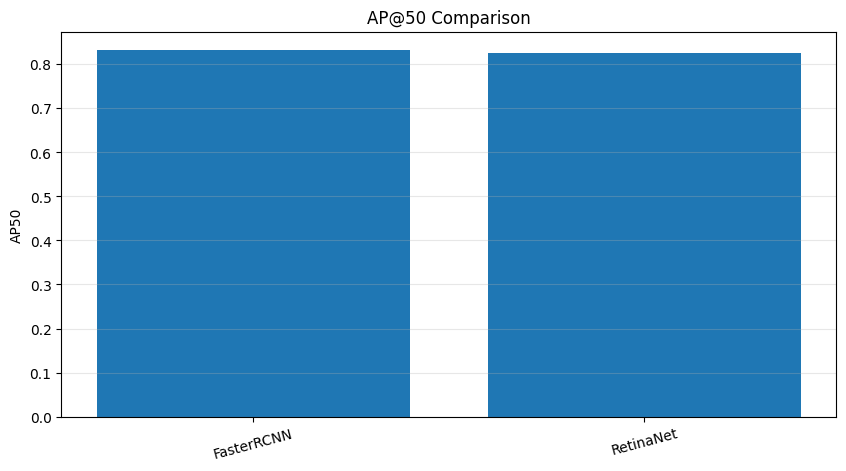

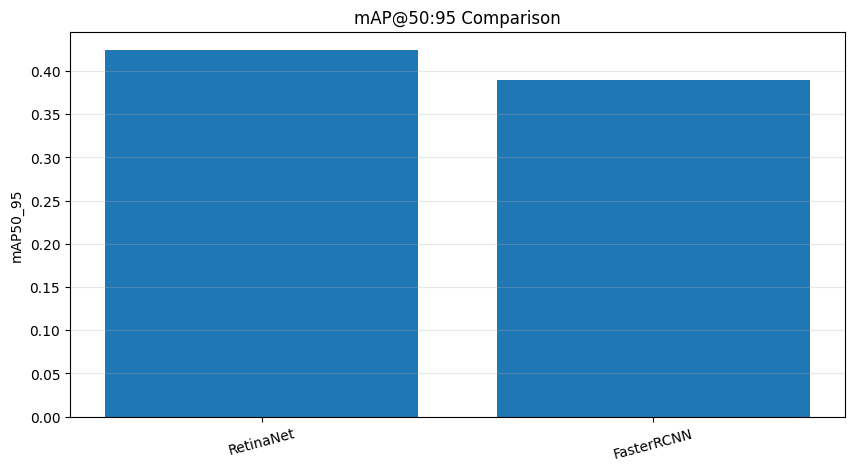

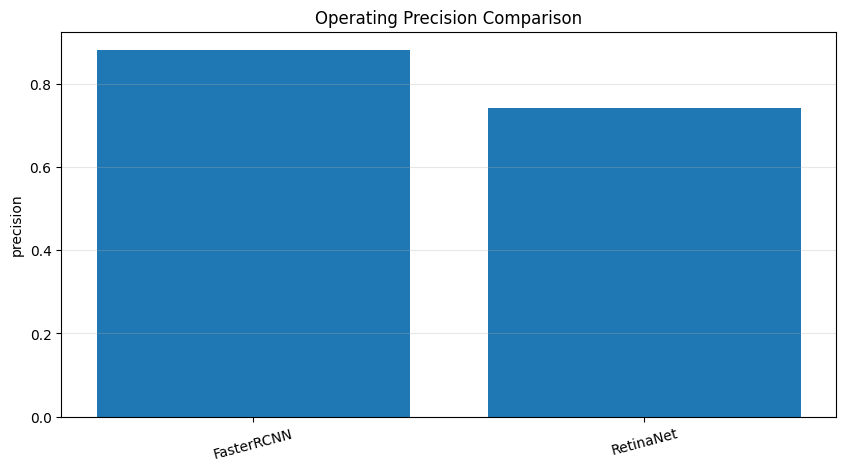

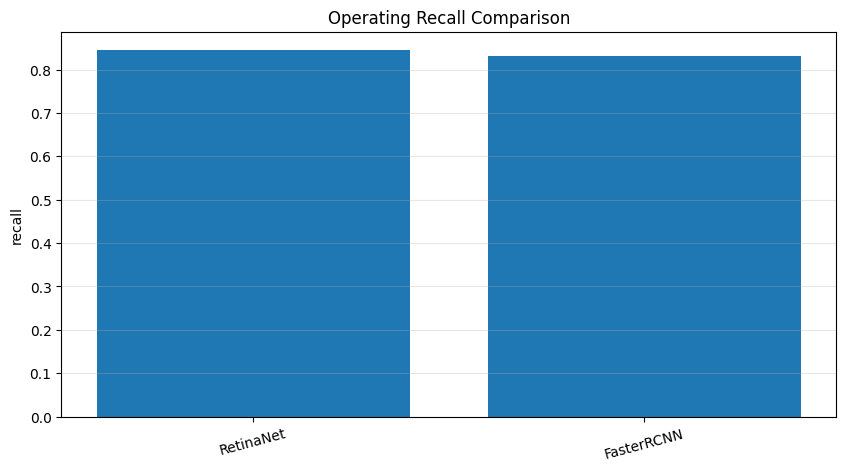

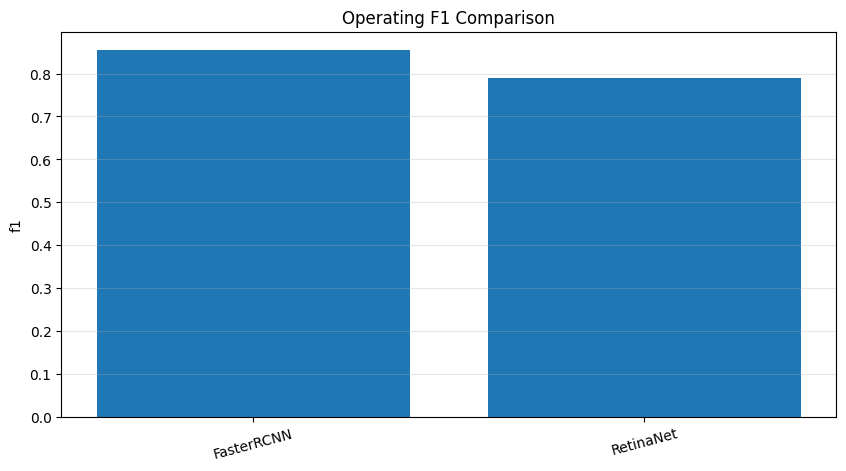

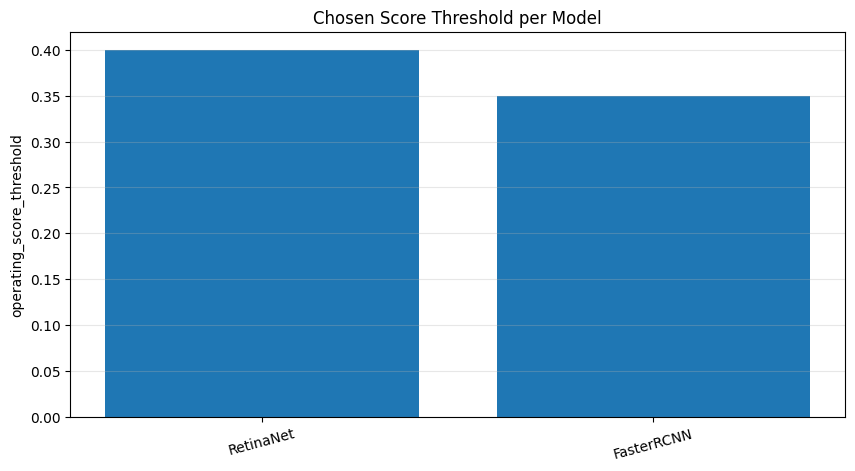

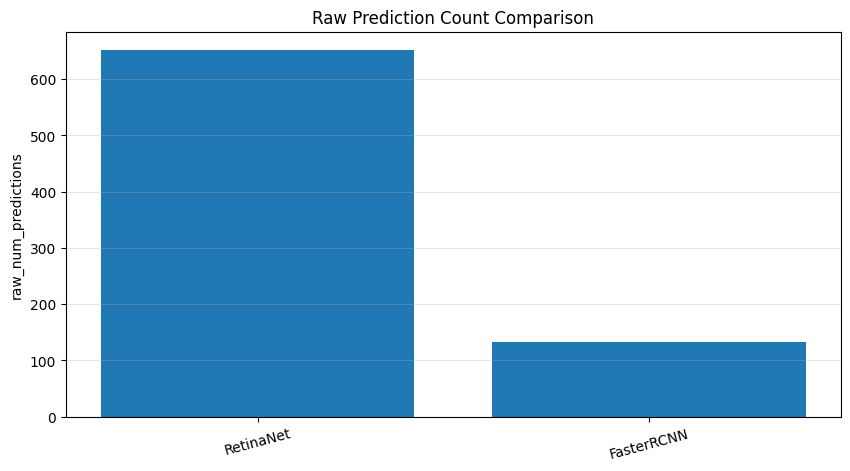

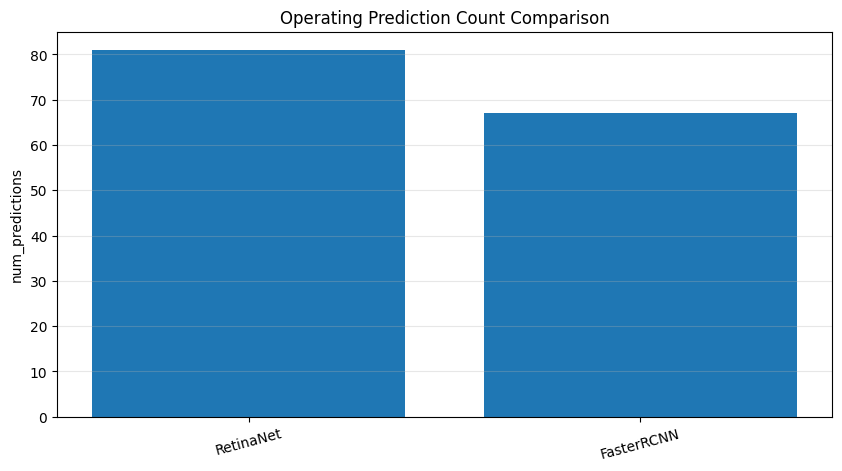

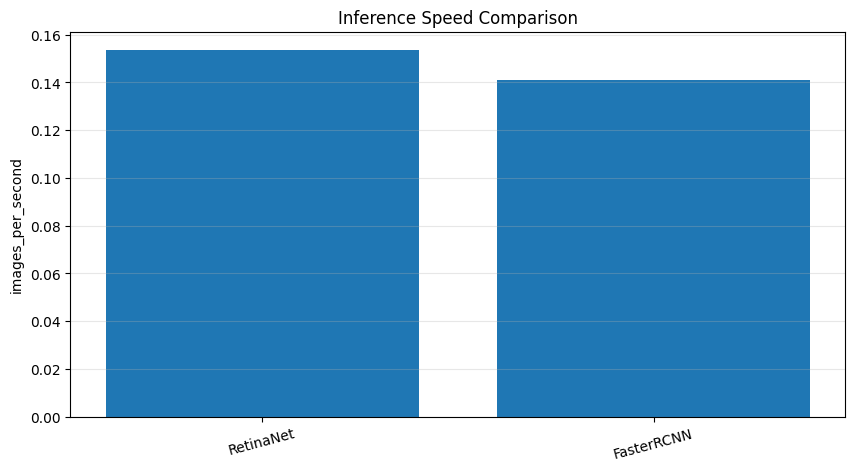

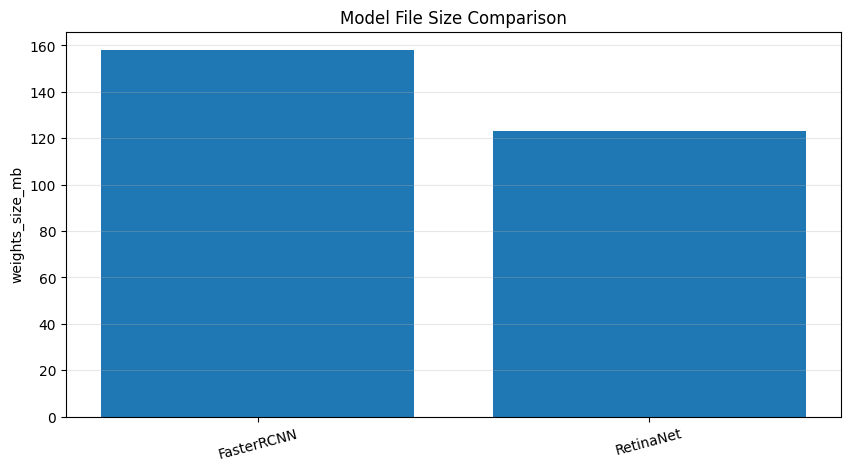

In [15]:

def simple_bar(df, metric, title):
    if df.empty or metric not in df.columns:
        print(f"Metric not found: {metric}")
        return
    plot_df = df.sort_values(metric, ascending=False)
    plt.figure(figsize=(10, 5))
    plt.bar(plot_df["model_name"], plot_df[metric])
    plt.title(title)
    plt.ylabel(metric)
    plt.xticks(rotation=15)
    plt.grid(axis="y", alpha=0.3)
    plt.show()

simple_bar(report_table, "AP50", "AP@50 Comparison")
simple_bar(report_table, "mAP50_95", "mAP@50:95 Comparison")
simple_bar(report_table, "precision", "Operating Precision Comparison")
simple_bar(report_table, "recall", "Operating Recall Comparison")
simple_bar(report_table, "f1", "Operating F1 Comparison")
simple_bar(report_table, "operating_score_threshold", "Chosen Score Threshold per Model")
simple_bar(report_table, "raw_num_predictions", "Raw Prediction Count Comparison")
simple_bar(report_table, "num_predictions", "Operating Prediction Count Comparison")
simple_bar(report_table, "images_per_second", "Inference Speed Comparison")
simple_bar(report_table, "weights_size_mb", "Model File Size Comparison")


## 10.1) Threshold sweep diagnostics

This is the key safeguard against misleadingly low precision for RetinaNet or Faster R-CNN.
It shows how precision, recall, and F1 change as you raise the score threshold.


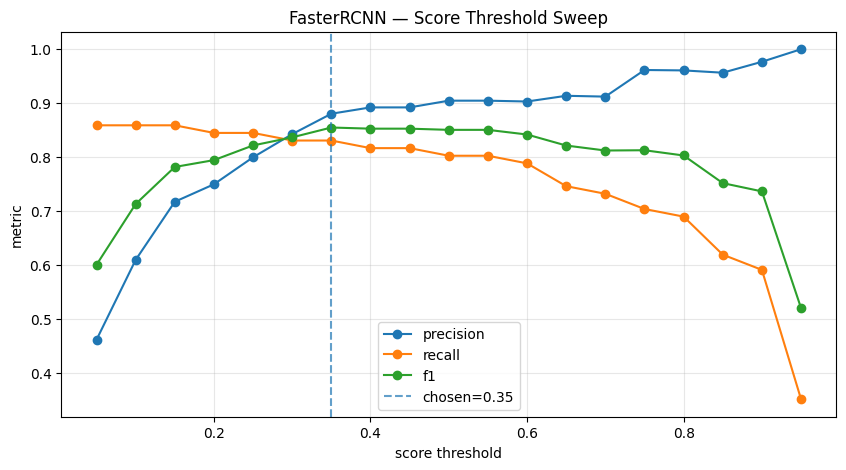

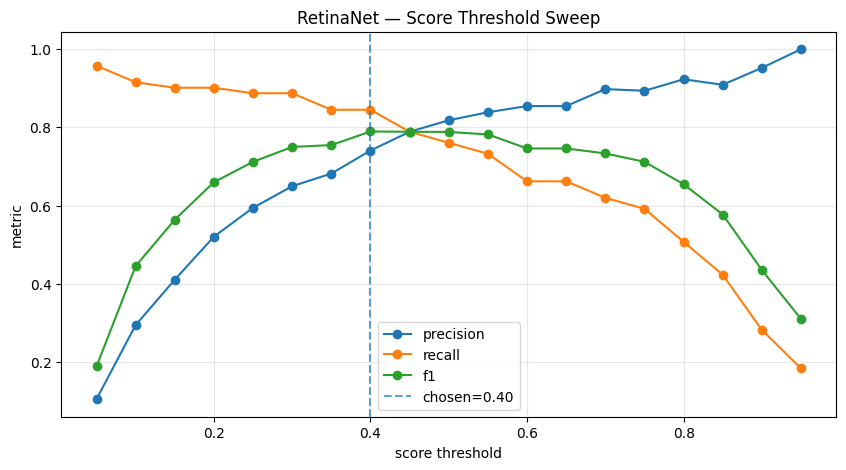

In [16]:

if 'threshold_sweeps_df' in globals() and not threshold_sweeps_df.empty:
    for model_name in threshold_sweeps_df["model_name"].dropna().unique():
        sub = threshold_sweeps_df[threshold_sweeps_df["model_name"] == model_name].copy()
        plt.figure(figsize=(10, 5))
        plt.plot(sub["score_threshold"], sub["precision"], marker="o", label="precision")
        plt.plot(sub["score_threshold"], sub["recall"], marker="o", label="recall")
        plt.plot(sub["score_threshold"], sub["f1"], marker="o", label="f1")
        best_thr = summary_df.loc[summary_df["model_name"] == model_name, "operating_score_threshold"].iloc[0]
        plt.axvline(best_thr, linestyle="--", alpha=0.7, label=f"chosen={best_thr:.2f}")
        plt.title(f"{model_name} — Score Threshold Sweep")
        plt.xlabel("score threshold")
        plt.ylabel("metric")
        plt.grid(alpha=0.3)
        plt.legend()
        plt.show()
else:
    print("No threshold sweep data available.")


## 11) AP across IoU thresholds

This helps the report discussion because it shows:
- whether a model is only good at loose matching
- or remains strong at stricter localization thresholds

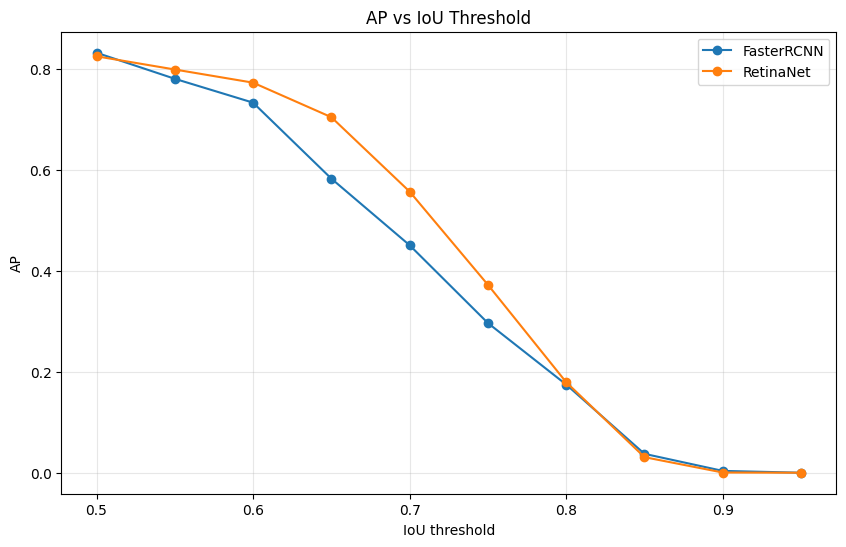

In [17]:

if not all_thresholds_df.empty:
    plt.figure(figsize=(10, 6))
    for model_name, sub in all_thresholds_df.groupby("model_name"):
        sub = sub.sort_values("iou_threshold")
        plt.plot(sub["iou_threshold"], sub["ap"], marker="o", label=model_name)
    plt.title("AP vs IoU Threshold")
    plt.xlabel("IoU threshold")
    plt.ylabel("AP")
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.show()

## 12) Precision–Recall curves at IoU 0.50

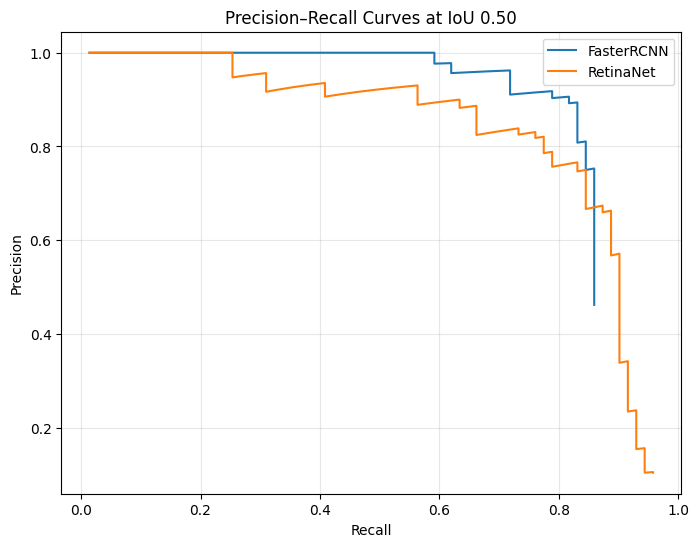

In [18]:

if not all_matches_df.empty:
    plt.figure(figsize=(8, 6))
    for model_name, sub in all_matches_df.groupby("model_name"):
        if len(sub) == 0:
            continue
        sub = sub.sort_values("score", ascending=False).copy()
        total_gt = int(gt_df["gt_index"].count())
        sub["cum_tp"] = sub["is_tp"].cumsum()
        sub["cum_fp"] = sub["is_fp"].cumsum()
        sub["precision_curve"] = sub["cum_tp"] / (sub["cum_tp"] + sub["cum_fp"])
        sub["recall_curve"] = sub["cum_tp"] / max(total_gt, 1)
        plt.plot(sub["recall_curve"], sub["precision_curve"], label=model_name)
    plt.title("Precision–Recall Curves at IoU 0.50")
    plt.xlabel("Recall")
    plt.ylabel("Precision")
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.show()

## 13) Training-history comparison when available

This uses:
- YOLO `results.csv`
- Faster R-CNN `fasterrcnn_results.json`
- RetinaNet `retinanet_results.json`

These are not perfectly identical training logs, but they are still useful for:
- convergence behavior
- stability
- best validation behavior
- loss trends

In [19]:

def discover_yolo_result_csvs() -> List[Path]:
    paths = []
    detect_root = PROJECT_ROOT / "runs" / "detect"
    if detect_root.exists():
        for p in detect_root.glob("*/results.csv"):
            paths.append(p)
    return sorted(paths)

def load_yolo_histories() -> Dict[str, pd.DataFrame]:
    histories = {}
    for p in discover_yolo_result_csvs():
        try:
            df = pd.read_csv(p)
            df = normalize_columns(df)
            histories[p.parent.name] = df
        except Exception as e:
            print(f"Could not load {p}: {e}")
    return histories

def load_torchvision_history(path: Path, model_name: str) -> Optional[pd.DataFrame]:
    data = load_json(path)
    if not data or "history" not in data:
        return None
    hist = data["history"]
    max_len = max(len(v) for v in hist.values()) if hist else 0
    df = pd.DataFrame({"epoch": list(range(1, max_len + 1))})
    for k, v in hist.items():
        df[k] = pd.Series(v)
    df["model_name"] = model_name
    return df

yolo_histories = load_yolo_histories()
faster_hist_df = load_torchvision_history(FASTER_RESULTS_JSON, "FasterRCNN") if FASTER_RESULTS_JSON.exists() else None
retina_hist_df = load_torchvision_history(RETINA_RESULTS_JSON, "RetinaNet") if RETINA_RESULTS_JSON.exists() else None

print("YOLO histories found:", list(yolo_histories.keys()))
print("Faster history available:", faster_hist_df is not None)
print("Retina history available:", retina_hist_df is not None)

YOLO histories found: []
Faster history available: True
Retina history available: True


In [20]:

# YOLO curves
for run_name, df in yolo_histories.items():
    possible_epoch_col = "epoch" if "epoch" in df.columns else None
    x = df[possible_epoch_col] if possible_epoch_col else np.arange(len(df))

    plt.figure(figsize=(10, 4))
    plotted = False
    for col in ["train_box_loss", "train_cls_loss", "train_dfl_loss"]:
        if col in df.columns:
            plt.plot(x, df[col], marker="o", label=col)
            plotted = True
    plt.title(f"YOLO Training Loss Components — {run_name}")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.grid(True, alpha=0.3)
    if plotted:
        plt.legend()
        plt.show()

    plt.figure(figsize=(10, 4))
    plotted = False
    for col in ["metrics_precisionB", "metrics_recallB", "metrics_mAP50B", "metrics_mAP50_95B"]:
        if col in df.columns:
            plt.plot(x, df[col], marker="o", label=col)
            plotted = True
    plt.title(f"YOLO Validation Metrics — {run_name}")
    plt.xlabel("Epoch")
    plt.ylabel("Score")
    plt.grid(True, alpha=0.3)
    if plotted:
        plt.legend()
        plt.show()

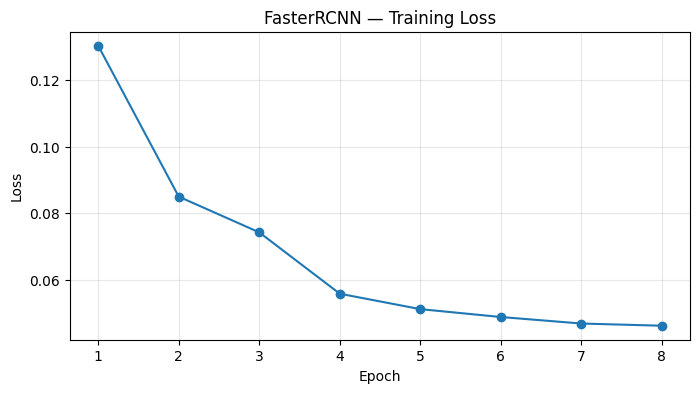

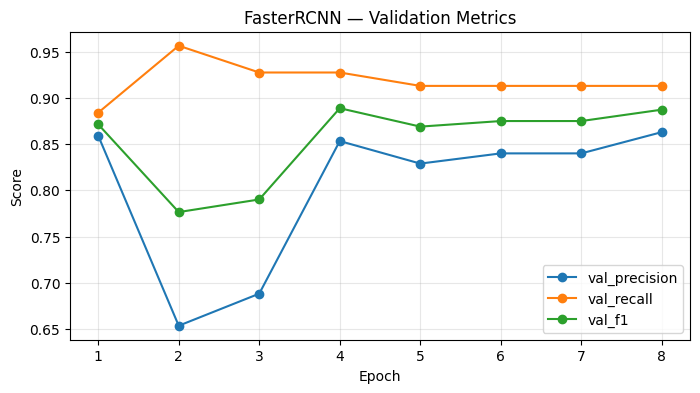

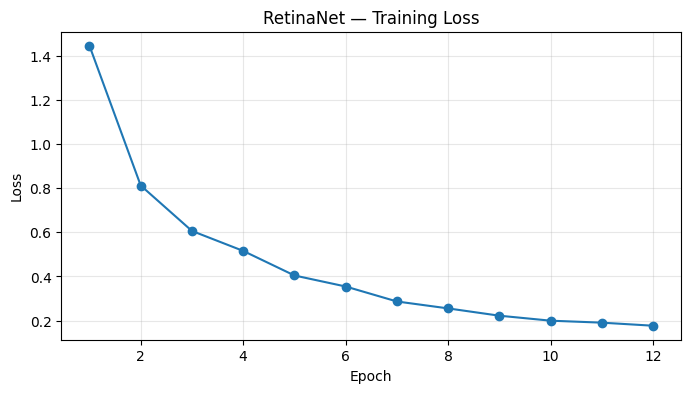

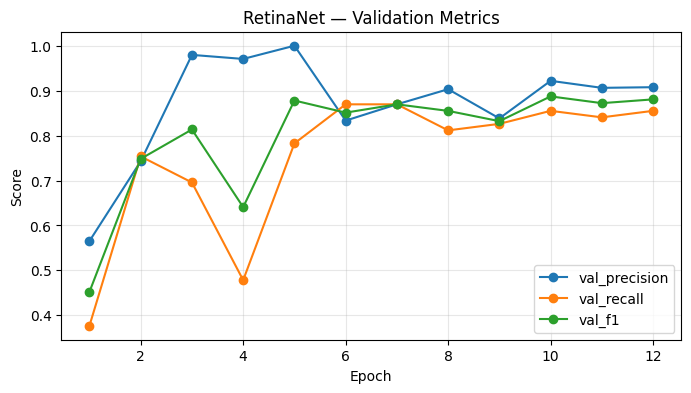

In [21]:

# Faster R-CNN and RetinaNet histories
history_frames = [df for df in [faster_hist_df, retina_hist_df] if df is not None]
for df in history_frames:
    model_name = df["model_name"].iloc[0]

    if "train_loss" in df.columns:
        plt.figure(figsize=(8, 4))
        plt.plot(df["epoch"], df["train_loss"], marker="o")
        plt.title(f"{model_name} — Training Loss")
        plt.xlabel("Epoch")
        plt.ylabel("Loss")
        plt.grid(True, alpha=0.3)
        plt.show()

    metric_cols = [c for c in ["val_precision", "val_recall", "val_f1"] if c in df.columns]
    if metric_cols:
        plt.figure(figsize=(8, 4))
        for c in metric_cols:
            plt.plot(df["epoch"], df[c], marker="o", label=c)
        plt.title(f"{model_name} — Validation Metrics")
        plt.xlabel("Epoch")
        plt.ylabel("Score")
        plt.grid(True, alpha=0.3)
        plt.legend()
        plt.show()

## 14) Final training-summary table

This section extracts the final / best training-side results that were saved during training.

In [22]:

training_summary_rows = []

# YOLO
for run_name, df in yolo_histories.items():
    row = {"model_name": f"YOLOv8_{run_name}"}
    best_idx = None
    for c in ["metrics_mAP50_95B", "metrics_mAP50B", "metrics_precisionB"]:
        if c in df.columns:
            best_idx = int(df[c].astype(float).idxmax())
            break
    if best_idx is None:
        best_idx = len(df) - 1
    best_row = df.iloc[best_idx]

    row["source"] = f"runs/detect/{run_name}/results.csv"
    row["best_epoch_index"] = int(best_idx)
    row["train_loss_snapshot"] = safe_float(best_row["train_box_loss"]) if "train_box_loss" in df.columns else np.nan
    row["val_precision"] = safe_float(best_row["metrics_precisionB"]) if "metrics_precisionB" in df.columns else np.nan
    row["val_recall"] = safe_float(best_row["metrics_recallB"]) if "metrics_recallB" in df.columns else np.nan
    row["val_map50"] = safe_float(best_row["metrics_mAP50B"]) if "metrics_mAP50B" in df.columns else np.nan
    row["val_map50_95"] = safe_float(best_row["metrics_mAP50_95B"]) if "metrics_mAP50_95B" in df.columns else np.nan
    training_summary_rows.append(row)

# Faster / Retina
for path, model_name in [(FASTER_RESULTS_JSON, "FasterRCNN"), (RETINA_RESULTS_JSON, "RetinaNet")]:
    if path.exists():
        data = load_json(path)
        if data:
            row = {
                "model_name": model_name,
                "source": str(path),
                "best_epoch_index": np.nan,
                "train_loss_snapshot": np.nan,
                "val_precision": np.nan,
                "val_recall": np.nan,
                "val_map50": np.nan,
                "val_map50_95": np.nan,
                "best_val_f1": safe_float(data.get("best_val_f1")),
            }
            hist = data.get("history", {})
            if isinstance(hist, dict) and len(hist) > 0:
                val_f1 = hist.get("val_f1", [])
                if len(val_f1) > 0:
                    best_idx = int(np.argmax(val_f1))
                    row["best_epoch_index"] = best_idx + 1
                    row["val_precision"] = safe_float(hist.get("val_precision", [np.nan]*len(val_f1))[best_idx])
                    row["val_recall"] = safe_float(hist.get("val_recall", [np.nan]*len(val_f1))[best_idx])
                    row["best_val_f1"] = safe_float(val_f1[best_idx])
                    row["train_loss_snapshot"] = safe_float(hist.get("train_loss", [np.nan]*len(val_f1))[best_idx])
            training_summary_rows.append(row)

training_summary_df = pd.DataFrame(training_summary_rows)
training_summary_df.to_csv(ANALYSIS_DIR / "phase7_training_summary.csv", index=False)
training_summary_df

,model_name,source,best_epoch_index,train_loss_snapshot,val_precision,val_recall,val_map50,val_map50_95,best_val_f1
0,FasterRCNN,C:\Users\jjrjg\OneDrive\Desktop\CMPS 261 Project\Plate-Detection-Project\fasterrcnn_outputs\fasterrcnn_results.json,4,0.055740,0.853333,0.927536,NaN,NaN,0.888889
1,RetinaNet,C:\Users\jjrjg\OneDrive\Desktop\CMPS 261 Project\Plate-Detection-Project\retinanet_outputs\retinanet_results.json,10,0.199658,0.921875,0.855072,NaN,NaN,0.887218


## 15) Error analysis

This section identifies:
- strongest false positives
- missed images
- low-IoU detections
- best detections

These examples are useful for your report's qualitative discussion.

In [23]:

if not all_matches_df.empty:
    fp_examples = (
        all_matches_df[all_matches_df["is_fp"] == 1]
        .sort_values("score", ascending=False)
        .groupby("model_name", as_index=False)
        .head(10)
    )

    best_tp_examples = (
        all_matches_df[all_matches_df["is_tp"] == 1]
        .sort_values("best_iou", ascending=False)
        .groupby("model_name", as_index=False)
        .head(10)
    )

    hard_tp_examples = (
        all_matches_df[all_matches_df["is_tp"] == 1]
        .sort_values("best_iou", ascending=True)
        .groupby("model_name", as_index=False)
        .head(10)
    )

    fp_examples.to_csv(ANALYSIS_DIR / "phase7_false_positive_examples.csv", index=False)
    best_tp_examples.to_csv(ANALYSIS_DIR / "phase7_best_tp_examples.csv", index=False)
    hard_tp_examples.to_csv(ANALYSIS_DIR / "phase7_hard_tp_examples.csv", index=False)

    print("False positive examples:")
    display(fp_examples.head(15))

    print("Best true positive examples:")
    display(best_tp_examples.head(15))

    print("Hard / low-IoU true positive examples:")
    display(hard_tp_examples.head(15))

False positive examples:


,model_name,image_stem,score,pred_box,best_iou,matched_gt_index,is_tp,is_fp,iou_threshold,cum_tp,cum_fp,precision_curve,recall_curve
150,RetinaNet,Cars405,0.914592,"[245.8546905517578, 213.25523376464844, 293.5964660644531, 226.95811462402344]",0.451172,-1,0,1,0.5,18,1,0.947368,0.253521
42,FasterRCNN,Cars236,0.901755,"[225.2066650390625, 108.62278747558594, 245.54795837402344, 116.66938018798828]",0.466319,-1,0,1,0.5,42,1,0.976744,0.591549
155,RetinaNet,Cars202,0.889981,"[198.26951599121094, 140.156494140625, 244.68295288085938, 151.52354431152344]",0.422743,-1,0,1,0.5,22,2,0.916667,0.309859
163,RetinaNet,Cars106,0.857402,"[138.9857940673828, 79.16390991210938, 164.80592346191406, 86.1729965209961]",0.356954,-1,0,1,0.5,29,3,0.906250,0.408451
45,FasterRCNN,Cars14,0.854925,"[158.13888549804688, 114.4157943725586, 278.739501953125, 155.051513671875]",0.492983,-1,0,1,0.5,44,2,0.956522,0.619718
175,RetinaNet,Cars236,0.781635,"[224.7100372314453, 109.92159271240234, 245.84288024902344, 115.03887176513672]",0.308099,-1,0,1,0.5,40,4,0.909091,0.563380
176,RetinaNet,Cars106,0.780964,"[229.88526916503906, 200.07791137695312, 275.9267578125, 210.96775817871094]",0.403691,-1,0,1,0.5,40,5,0.888889,0.563380
54,FasterRCNN,Cars102,0.729210,"[164.44493103027344, 141.41668701171875, 317.11846923828125, 202.5429229736328]",0.000000,-1,0,1,0.5,51,4,0.927273,0.718310
53,FasterRCNN,Cars282,0.729210,"[164.44493103027344, 141.41668701171875, 317.11846923828125, 202.5429229736328]",0.000000,-1,0,1,0.5,51,3,0.944444,0.718310
55,FasterRCNN,Cars106,0.726639,"[139.07395935058594, 78.5970230102539, 165.02798461914062, 87.87715911865234]",0.445249,-1,0,1,0.5,51,5,0.910714,0.718310


Best true positive examples:


,model_name,image_stem,score,pred_box,best_iou,matched_gt_index,is_tp,is_fp,iou_threshold,cum_tp,cum_fp,precision_curve,recall_curve
181,RetinaNet,Cars12,0.692544,"[119.16291809082031, 82.21822357177734, 272.11724853515625, 116.67524719238281]",0.936596,0,1,0,0.5,45,5,0.900000,0.633803
44,FasterRCNN,Cars300,0.875166,"[259.3631896972656, 184.1176300048828, 319.2998962402344, 215.31997680664062]",0.919217,0,1,0,0.5,44,1,0.977778,0.619718
43,FasterRCNN,Cars51,0.881508,"[262.4636535644531, 141.6817169189453, 317.981689453125, 162.52561950683594]",0.918300,0,1,0,0.5,43,1,0.977273,0.605634
11,FasterRCNN,Cars304,0.971831,"[139.95391845703125, 113.17648315429688, 220.02401733398438, 155.2074432373047]",0.904402,0,1,0,0.5,12,0,1.000000,0.169014
243,RetinaNet,Cars211,0.236057,"[5.031999588012695, 70.0040512084961, 388.8815002441406, 236.69366455078125]",0.895589,0,1,0,0.5,64,48,0.571429,0.901408
156,RetinaNet,Cars167,0.889690,"[176.79188537597656, 255.70228576660156, 325.19281005859375, 283.9180603027344]",0.894520,0,1,0,0.5,23,2,0.920000,0.323944
46,FasterRCNN,Cars313,0.848098,"[177.37924194335938, 209.68402099609375, 253.1834259033203, 247.903076171875]",0.886702,0,1,0,0.5,45,2,0.957447,0.633803
4,FasterRCNN,Cars96,0.980052,"[135.198486328125, 123.33985137939453, 257.4595642089844, 160.1310272216797]",0.885713,0,1,0,0.5,5,0,1.000000,0.070423
27,FasterRCNN,Cars83,0.947507,"[249.7933807373047, 295.8461608886719, 328.1102294921875, 338.21148681640625]",0.884941,0,1,0,0.5,28,0,1.000000,0.394366
192,RetinaNet,Cars102,0.571141,"[50.831172943115234, 145.26913452148438, 324.79693603515625, 200.2186737060547]",0.884266,0,1,0,0.5,51,10,0.836066,0.718310


Hard / low-IoU true positive examples:


,model_name,image_stem,score,pred_box,best_iou,matched_gt_index,is_tp,is_fp,iou_threshold,cum_tp,cum_fp,precision_curve,recall_curve
8,FasterRCNN,Cars281,0.973273,"[148.5406494140625, 164.67636108398438, 238.092529296875, 190.58448791503906]",0.510416,0,1,0,0.5,9,0,1.000000,0.126761
193,RetinaNet,Cars196,0.570366,"[106.52849578857422, 130.0399169921875, 142.68446350097656, 140.8082275390625]",0.513166,0,1,0,0.5,52,10,0.838710,0.732394
178,RetinaNet,Cars96,0.752284,"[139.08543395996094, 127.21755981445312, 239.56297302246094, 150.06248474121094]",0.527436,0,1,0,0.5,42,5,0.893617,0.591549
22,FasterRCNN,Cars416,0.954510,"[148.68582153320312, 201.61756896972656, 234.8306427001953, 227.25242614746094]",0.532534,0,1,0,0.5,23,0,1.000000,0.323944
775,RetinaNet,Cars236,0.050269,"[225.04087829589844, 105.29100036621094, 245.91668701171875, 115.45641326904297]",0.539666,0,1,0,0.5,68,576,0.105590,0.957746
321,RetinaNet,Cars202,0.117261,"[200.74392700195312, 140.60098266601562, 242.99232482910156, 161.94093322753906]",0.566463,0,1,0,0.5,65,125,0.342105,0.915493
52,FasterRCNN,Cars211,0.739826,"[136.30059814453125, 38.97509002685547, 375.4015197753906, 253.29348754882812]",0.569871,0,1,0,0.5,51,2,0.962264,0.718310
6,FasterRCNN,Cars182,0.978235,"[151.9849395751953, 134.1162872314453, 249.84170532226562, 162.30459594726562]",0.572792,0,1,0,0.5,7,0,1.000000,0.098592
409,RetinaNet,Cars106,0.082450,"[232.01585388183594, 191.06231689453125, 275.1649169921875, 212.32215881347656]",0.577592,3,1,0,0.5,66,212,0.237410,0.929577
180,RetinaNet,Cars203,0.744050,"[125.8652114868164, 119.2779769897461, 276.8905944824219, 153.08865356445312]",0.583196,0,1,0,0.5,44,5,0.897959,0.619718


In [24]:

def show_example_for_model(model_name: str, image_stem: str):
    image_path = get_image_path_from_stem(image_stem)
    if image_path is None:
        print("Image not found.")
        return

    image = np.array(Image.open(image_path).convert("RGB"))
    gt_boxes = gt_lookup.get(image_stem, [])

    sub_preds = pred_df[(pred_df["model_name"] == model_name) & (pred_df["image_stem"] == image_stem) & (pred_df["pred_box"].notna())].copy()
    sub_preds = sub_preds.sort_values("score", ascending=False)
    pred_boxes = sub_preds["pred_box"].tolist()[:5]
    pred_scores = sub_preds["score"].tolist()[:5]

    draw_boxes(
        image=image,
        gt_boxes=gt_boxes,
        pred_boxes=pred_boxes,
        pred_scores=pred_scores,
        title=f"{model_name} — {image_stem}"
    )

# Example:
# show_example_for_model(report_table.iloc[0]['model_name'], EVAL_STEMS[0])

## 16) Simple automatic interpretation draft

This cell gives you a first-pass discussion that you can refine for the report.

In [ ]:

def summarize_strengths(report_table: pd.DataFrame) -> str:
    if report_table.empty:
        return "No results available."

    best_map = report_table.sort_values("mAP50_95", ascending=False).iloc[0]
    best_ap50 = report_table.sort_values("AP50", ascending=False).iloc[0]
    best_recall = report_table.sort_values("recall", ascending=False).iloc[0]
    best_precision = report_table.sort_values("precision", ascending=False).iloc[0]
    fastest = report_table.sort_values("images_per_second", ascending=False).iloc[0]
    smallest = report_table.sort_values("weights_size_mb", ascending=True).iloc[0]

    lines = []
    lines.append(f"Best overall localization quality by mAP@50:95: {best_map['model_name']} ({best_map['mAP50_95']:.4f}).")
    lines.append(f"Best relaxed-threshold detection by AP@50: {best_ap50['model_name']} ({best_ap50['AP50']:.4f}).")
    lines.append(f"Highest recall:qq {best_recall['model_name']} ({best_recall['recall']:.4f}).")
    lines.append(f"Highest precision: {best_precision['model_name']} ({best_precision['precision']:.4f}).")
    lines.append(f"Fastest inference: {fastest['model_name']} ({fastest['images_per_second']:.2f} images/sec).")
    lines.append(f"Smallest weight file: {smallest['model_name']} ({smallest['weights_size_mb']:.2f} MB).")

    lines.append("")
    lines.append("Interpretation guide:")
    lines.append("- If the same model leads both AP@50 and mAP@50:95, it is likely the strongest overall detector.")
    lines.append("- A model with high recall but lower precision is finding more plates but also producing more false positives.")
    lines.append("- A model with strong AP@50 but weaker mAP@50:95 usually localizes roughly well but is less accurate at tighter IoU thresholds.")
    lines.append("- Faster inference and smaller weights matter if deployment efficiency is part of the project discussion.")

    return "\n".join(lines)

print(summarize_strengths(report_table))

Best overall localization quality by mAP@50:95: RetinaNet (0.4242).
Best relaxed-threshold detection by AP@50: FasterRCNN (0.8324).
Highest recall: RetinaNet (0.8451).
Highest precision: FasterRCNN (0.8806).
Fastest inference: RetinaNet (0.15 images/sec).
Smallest weight file: RetinaNet (123.23 MB).

Interpretation guide:
- If the same model leads both AP@50 and mAP@50:95, it is likely the strongest overall detector.
- A model with high recall but lower precision is finding more plates but also producing more false positives.
- A model with strong AP@50 but weaker mAP@50:95 usually localizes roughly well but is less accurate at tighter IoU thresholds.
- Faster inference and smaller weights matter if deployment efficiency is part of the project discussion.


## 17) Export everything needed for the report

Generated files go to `analysis_outputs/`

In [26]:

export_files = sorted(ANALYSIS_DIR.glob("*"))
for p in export_files:
    print(p.name)

FasterRCNN_raw_predictions.csv
phase7_best_tp_examples.csv
phase7_detection_all_thresholds.csv
phase7_detection_matches.csv
phase7_detection_summary.csv
phase7_false_positive_examples.csv
phase7_hard_tp_examples.csv
phase7_report_table.csv
phase7_threshold_sweeps.csv
phase7_training_summary.csv
RetinaNet_raw_predictions.csv
